In [1]:
import numpy as np
#import numpy.random as npr
import pandas as pd
import matplotlib.pyplot as plt
from astropy import units as u
import matplotlib.cm as mcm
import scipy.stats as sts
from matplotlib import ticker
import numpy.ma as nma
from sklearn.feature_selection import mutual_info_regression
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

plt.style.use('./presentation.mplstyle')


In [2]:
sources = pd.read_csv('v1saga_dwarfs.csv')
print(sources.shape)

smorph = pd.read_csv('saga_morph.csv')
print(smorph.shape)

galex = pd.read_csv('v1GALEX_dwarfs.csv')
print(np.shape(galex))

(6337, 26)
(6211, 78)
(6337, 15)


In [3]:
rd2deg = (180*3600)/np.pi

#mst = sources['logM'].iloc[morph_all[high_snr,i,0]]
#zspec = sources['zspec'].iloc[morph_all[high_snr,i,0]]
#res = 1e6*(0.262*cosmo.comoving_distance(zspec).value)/rd2deg

bands = {'r':[mcm.Greens,'tab:green'],'g':[mcm.Blues,'tab:blue'],'i':[mcm.Oranges,'tab:orange'],'z':[mcm.Reds,'tab:red']}
positions = [0, 1, 2, 3]
labels = [r'${\it r}$', r'${\it g}$',  r'${\it i}$', r'${\it z}$']

npr = {'gini':[[0.4,0.6],r'$Gini$',r'${\it Gini}$'],'m20':[[-2,-1],r'$M_{20}$',r'$M_{20}$'],
       'c':[[2,3.5],r'$Concentration$',r'${\it C_{CAS}}$'],'a':[[-0.3,0.3],r'$Asymmetry$',r'${\it A_{CAS}}$'],'s':[[-0.1,0.1],r'$Smoothness$',r'${\it S_{CAS}}$'],
       'rpetro':[[8,38],r'$Petrosian\ R$',r'$R_p$'],'n':[[0.0,4.0],r'$Sersic\ n$',r'${\it n}$'],'rhalf':[[0,20],r'$Sersic\ R$',r'$R_{0.5}$']}

def BGM(G,M20): return -0.693*M20 + 4.95*G - 3.96

(3385, 78) (2188, 78)
(2149, 78) (1359, 78)
(2181, 78) (1284, 78)


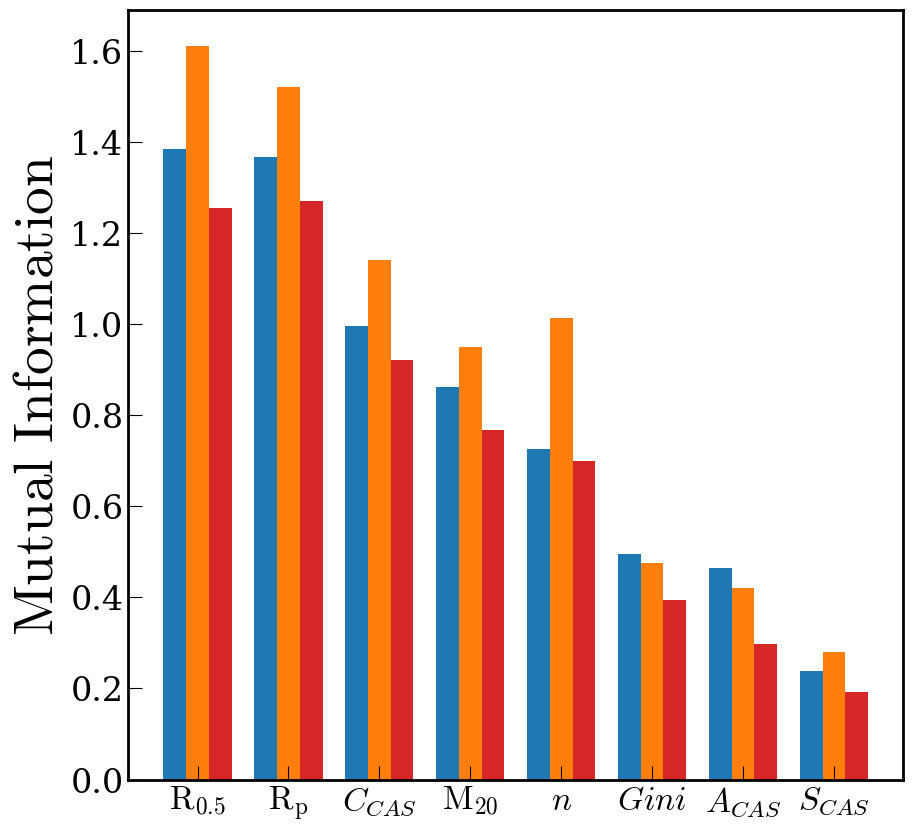

In [8]:
fig,ax=plt.subplots(figsize=(10,10))

mi_scores = np.ones((8,3))
param_pos = np.arange(8)
param_label = []

for j,key in enumerate(bands):
    if j>0:
        selc = smorph[(smorph['r20_psf_'+key]>0.5)&(smorph['snr_pix_'+key]>2.5)&(smorph['flag_'+key]<=1)&(smorph['r20_psf_r']>0.5)&(smorph['snr_pix_r']>2.5)&(smorph['flag_r']<=1)]
        selc_ss = smorph[(smorph['r20_psf_'+key]>0.5)&(smorph['snr_pix_'+key]>2.5)&(smorph['flag_ss_'+key]<=1)&(smorph['r20_psf_r']>0.5)&(smorph['snr_pix_r']>2.5)&(smorph['flag_ss_r']<=1)]
    
        print(selc.shape,selc_ss.shape)
    
        for i,ley in enumerate(npr):
            if i<6: mi_scores[i,j-1] = mutual_info_regression(selc[ley+'_'+key].values[:, np.newaxis], selc[ley+'_r'].values)
            else:  mi_scores[i,j-1] = mutual_info_regression(selc_ss[ley+'_'+key].values[:, np.newaxis], selc_ss[ley+'_r'].values)
    
            if j==1:    param_label.append(npr[ley][2])

width = 0.25  # the width of the bars
multiplier = 0

sorted_ind = np.flip((np.argsort(mi_scores[:,0])))
sorted_mi,sorted_lab = mi_scores[sorted_ind,:],[param_label[k] for k in sorted_ind]
    
for j,key in enumerate(bands):
    if j>0:
        offset = width * multiplier
        ax.bar(param_pos + offset, sorted_mi[:,j-1], width,color=bands[key][1])
        multiplier += 1    
ax.set_xticks(param_pos+width, labels=sorted_lab)
ax.set_ylabel(r'${\rm Mutual\ Information}$',fontsize=40)


plt.savefig('MIdistributions.pdf',bbox_inches='tight')

In [9]:
for j,ley in enumerate(npr):
    print(ley)
    for i,key in enumerate(bands):
        if i>0:
            print(key,sorted_lab[j],np.round(mi_scores[j,i-1],2))


gini
g $R_{0.5}$ 0.5
i $R_{0.5}$ 0.47
z $R_{0.5}$ 0.39
m20
g $R_p$ 0.86
i $R_p$ 0.95
z $R_p$ 0.77
c
g ${\it C_{CAS}}$ 1.0
i ${\it C_{CAS}}$ 1.14
z ${\it C_{CAS}}$ 0.92
a
g $M_{20}$ 0.47
i $M_{20}$ 0.42
z $M_{20}$ 0.3
s
g ${\it n}$ 0.24
i ${\it n}$ 0.28
z ${\it n}$ 0.19
rpetro
g ${\it Gini}$ 1.37
i ${\it Gini}$ 1.52
z ${\it Gini}$ 1.27
n
g ${\it A_{CAS}}$ 0.73
i ${\it A_{CAS}}$ 1.01
z ${\it A_{CAS}}$ 0.7
rhalf
g ${\it S_{CAS}}$ 1.38
i ${\it S_{CAS}}$ 1.61
z ${\it S_{CAS}}$ 1.26


(3947, 78) (2882, 78)


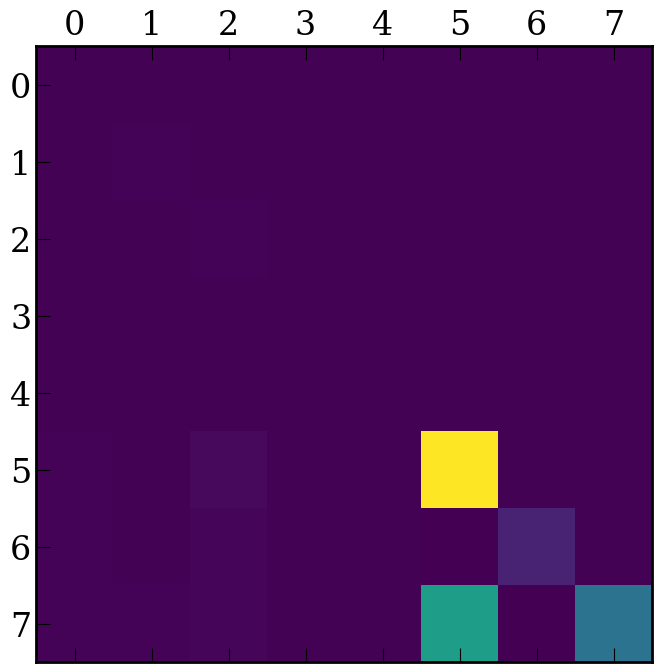

In [7]:
fig,ax=plt.subplots(figsize=(8,8))

mi_scores = np.ones((8,3))
param_pos = np.arange(8)
param_label = []

cov = np.zeros((8,8))

selc = smorph[(smorph['r20_psf_r']>0.5)&(smorph['snr_pix_r']>2.5)&(smorph['flag_r']<=1)]
selc_ss = smorph[(smorph['r20_psf_r']>0.5)&(smorph['snr_pix_r']>2.5)&(smorph['flag_ss_r']<=1)&(smorph['flag_r']<=1)]
    
print(selc.shape,selc_ss.shape)
    
for i,ley in enumerate(npr):
    for j,mey in enumerate(npr):
        if j<=i:
            if i<6: cov[i,j] = np.cov(selc[ley+'_r'].values,selc[mey+'_r'].values)[0][1]
            else:  cov[i,j] = np.cov(selc_ss[ley+'_r'].values,selc_ss[mey+'_r'].values)[0][1]
                
ax.matshow(cov)
#ax.set_ylabel(r'${\rm Mutual\ Information}$',fontsize=40)


#plt.savefig('MIdistributions.pdf',bbox_inches='tight')

In [12]:
gprop = pd.DataFrame()
gprop['ind'],gprop['logM'],gprop['zspec']=sources['ind'],sources['logM'],sources['zspec']
gprop['log_sfr'],gprop['flag_nondet']= galex['log_sfr'],galex['flag_nondet']
print(np.shape(gprop))

del galex

smerge = smorph.merge(right=gprop,how='left', left_on='ind0', right_on='ind')
print(smerge.shape)

(6337, 5)
(6211, 83)


In [5]:
mst_arr = np.linspace(7.0,10.0,21)
mst_bins = np.linspace(7.0,10.0,5)
mst_arr +=  0.5*(mst_arr[1]-mst_arr[0])

zsp_arr = np.linspace(0.0,0.1,21)
zsp_bins = np.linspace(0.0,0.1,5)
zsp_arr +=  0.5*(zsp_arr[1]-zsp_arr[0])

def eval_binstat(x,y,x_bins):
    nbin = len(x_bins)-1
    binstat = np.zeros((nbin,3))
    for i in range(nbin):
        inbin = np.where((x>x_bins[i])&(x<x_bins[i+1]))[0]
        binstat[i,0] = np.median(y[inbin])
        binstat[i,1:] = binstat[i,0]-np.percentile(y[inbin],q=16),np.percentile(y[inbin],q=84)-binstat[i,0]
    binedg = x_bins+ 0.5*(x_bins[1]-x_bins[0]) 
    return binstat,binedg